In [8]:
import pandas as pd
from dotenv import load_dotenv
import os, psycopg2

# Carregar variáveis de ambiente do arquivo .env
load_dotenv()

# Obter dados de conexão do .env
host = os.getenv("HOST")
database = os.getenv("DATABASE")
user= os.getenv("USER")
password= os.getenv("PASSWORD")

#trying again

#bruh momments

#conn local
conn = psycopg2.connect(host=host, database=database, user=user, password=password)
#conn nuvem
#conn = psycopg2.connect(host=host, database=database, user=user, password=password, sslmode='require')
cursor = conn.cursor()

In [9]:
select_all_query = """select * from public.selic
where fim_vigencia is not NULL"""

In [10]:
df = pd.read_sql_query(select_all_query, conn)

C:\Users\frodrigues\AppData\Local\Temp\ipykernel_27628\590896350.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(select_all_query, conn)


In [12]:
df_final = df

In [13]:
df.head()

,reuniao,data_reuniao,extraordinaria,vies,inicio_vigencia,fim_vigencia,taxa_selic,selic_acumulada_periodo,selic_media_anual
0,267ª,2024-12-11,False,não aplicável,2024-12-12,2025-01-29,12.25,1.51,12.15
1,266ª,2024-11-06,False,não aplicável,2024-11-07,2024-12-11,11.25,0.97,11.15
2,265ª,2024-09-18,False,não aplicável,2024-09-19,2024-11-06,10.75,1.42,10.65
3,264ª,2024-07-31,False,não aplicável,2024-08-01,2024-09-18,10.50,1.38,10.40
4,263ª,2024-06-19,False,não aplicável,2024-06-20,2024-07-31,10.50,1.18,10.40


<Axes: >

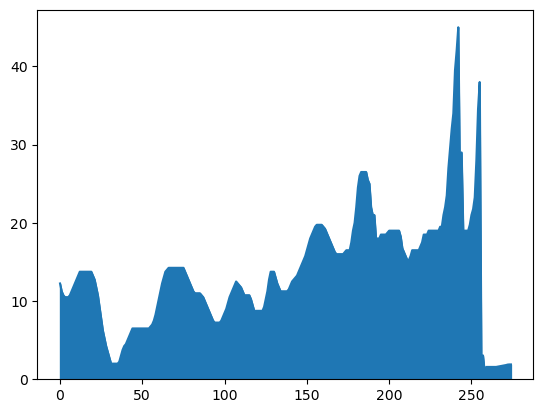

In [ ]:
#df_final.plot()
#df_final['taxa_selic'].hist()
#df_final.plot.scatter('taxa_selic', 'selic_media_anual') # gráfico de dispersão, mostra a correlação entre as variáveis
#df['taxa_selic'].plot(kind='density')
#df['taxa_selic'].plot(kind='area')

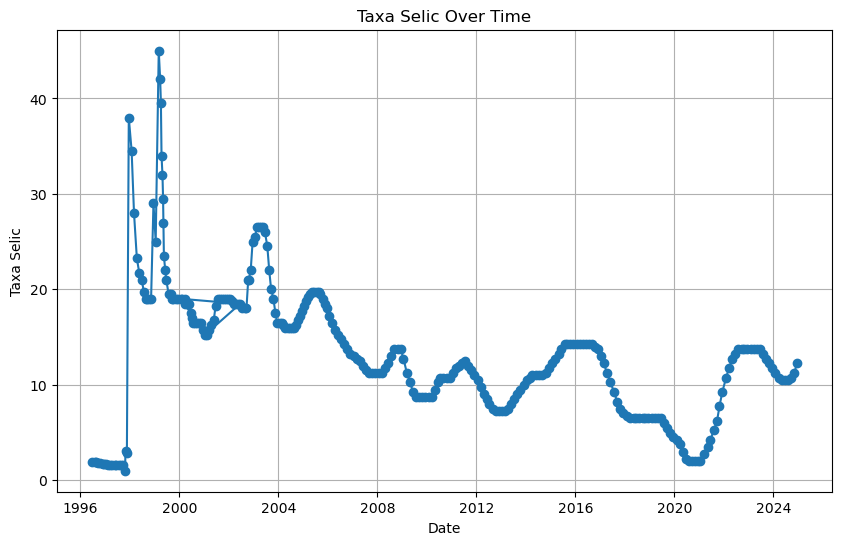

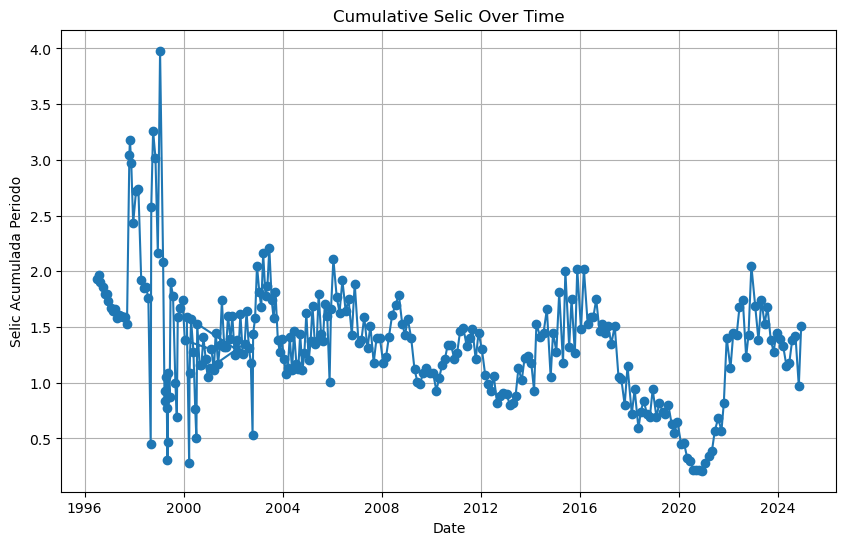

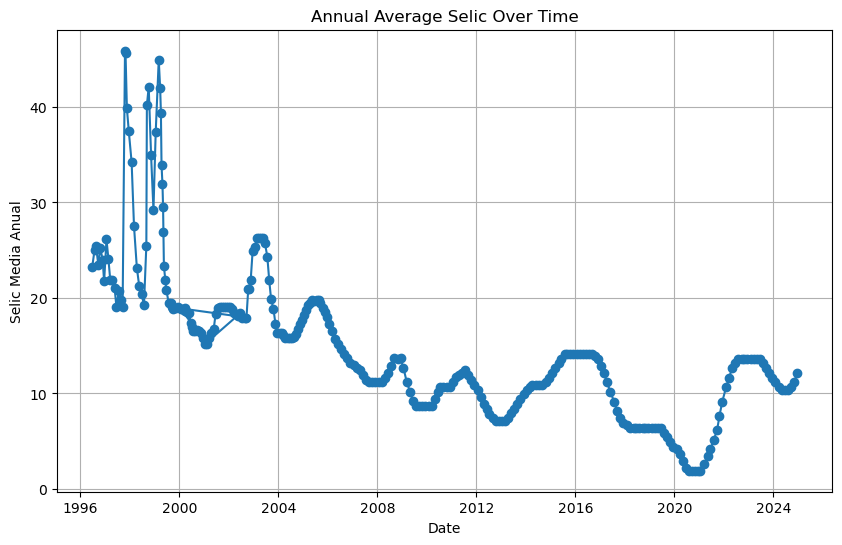

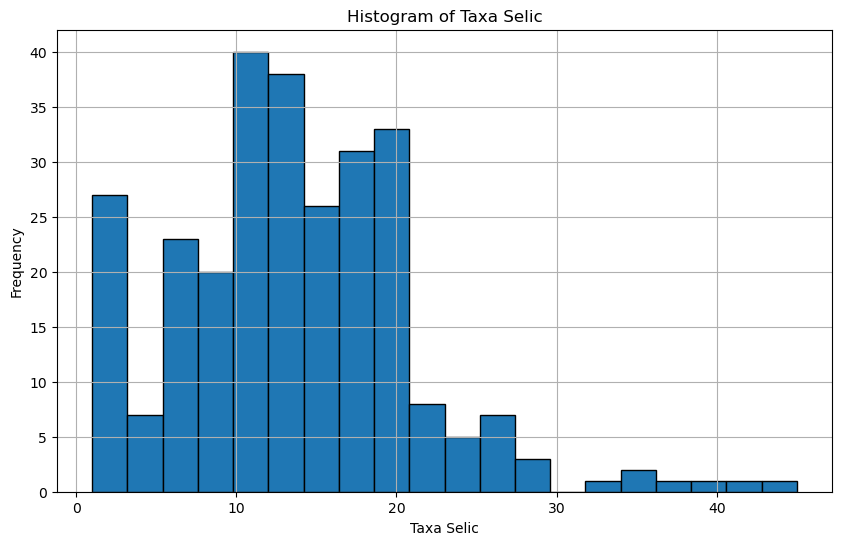

In [21]:
import matplotlib.pyplot as plt

# Plot Taxa Selic over time
plt.figure(figsize=(10, 6))
plt.plot(df_final['data_reuniao'], df_final['taxa_selic'], marker='o')
plt.title('Taxa Selic Over Time')
plt.xlabel('Date')
plt.ylabel('Taxa Selic')
plt.grid(True)
plt.show()

# Plot Cumulative Selic Over Time
plt.figure(figsize=(10, 6))
plt.plot(df_final['data_reuniao'], df_final['selic_acumulada_periodo'], marker='o')
plt.title('Cumulative Selic Over Time')
plt.xlabel('Date')
plt.ylabel('Selic Acumulada Periodo')
plt.grid(True)
plt.show()

# Plot Annual Average Selic Over Time
plt.figure(figsize=(10, 6))
plt.plot(df_final['data_reuniao'], df_final['selic_media_anual'], marker='o')
plt.title('Annual Average Selic Over Time')
plt.xlabel('Date')
plt.ylabel('Selic Media Anual')
plt.grid(True)
plt.show()

# Histogram of Taxa Selic
plt.figure(figsize=(10, 6))
plt.hist(df_final['taxa_selic'], bins=20, edgecolor='k')
plt.title('Histogram of Taxa Selic')
plt.xlabel('Taxa Selic')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

C:\Users\frodrigues\AppData\Local\Temp\ipykernel_27628\4148968831.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ipca_df = ipca_df.applymap(lambda x: float(x.replace('%', '').replace(',', '.')) if isinstance(x, str) else x)


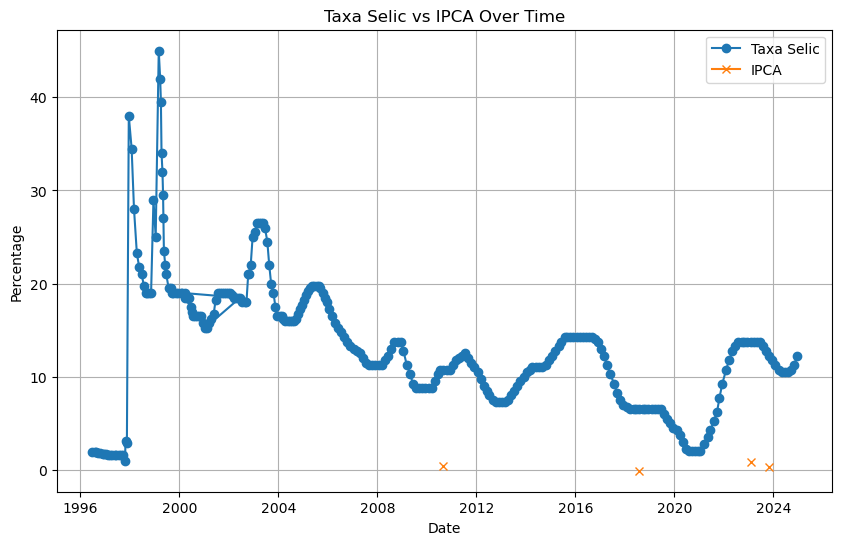

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the IPCA data from the CSV file
ipca_df = pd.read_csv('ipca_mensal.csv', delimiter=',', decimal=',', index_col=0)

# Replace '--' with NaN and remove '%' from the values
ipca_df.replace('--', pd.NA, inplace=True)
ipca_df = ipca_df.applymap(lambda x: float(x.replace('%', '').replace(',', '.')) if isinstance(x, str) else x)

# Map Portuguese month names to English abbreviations
month_map = {
    "Jan": "Jan", "Fev": "Feb", "Mar": "Mar", "Abr": "Apr", "Mai": "May", "Jun": "Jun",
    "Jul": "Jul", "Ago": "Aug", "Set": "Sep", "Out": "Oct", "Nov": "Nov", "Dez": "Dec"
}

# Melt the IPCA DataFrame to have a long format
ipca_df = ipca_df.reset_index().melt(id_vars='index', var_name='Month', value_name='IPCA')
ipca_df['Month'] = ipca_df['Month'].map(month_map)
ipca_df['Date'] = pd.to_datetime(ipca_df['index'].astype(str) + '-' + ipca_df['Month'], format='%Y-%b')
ipca_df = ipca_df.drop(columns=['index', 'Month'])

# Merge the IPCA data with the existing DataFrame containing the Taxa Selic data
df_final['data_reuniao'] = pd.to_datetime(df_final['data_reuniao'])
merged_df = pd.merge(df_final, ipca_df, left_on='data_reuniao', right_on='Date', how='left')

# Plot IPCA and Taxa Selic over time
plt.figure(figsize=(10, 6))
plt.plot(merged_df['data_reuniao'], merged_df['taxa_selic'], marker='o', label='Taxa Selic')
plt.plot(merged_df['data_reuniao'], merged_df['IPCA'], marker='x', label='IPCA')
plt.title('Taxa Selic vs IPCA Over Time')
plt.xlabel('Date')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True)
plt.show()